
# Comparación de inversión del background sintético desde semilla FIRI

Este notebook compara:

- parámetros **true**
- parámetros **iniciales**
- parámetros **reconstruidos**
- series temporales `target`, `initial` y `reco`

La métrica usada en los labels es el \(\chi^2\) normalizado de la inversión:

\[
\chi^2 =
\frac{\sum_i (A_i^\mathrm{model}-A_i^\mathrm{target})^2}{\sum_i (A_i^\mathrm{target}-\overline{A^\mathrm{target}})^2 + 10^{-12}}
+
\frac{\sum_i (\phi_i^\mathrm{target}-\phi_i^\mathrm{model})^2}{\sum_i (\phi_i^\mathrm{target}-\overline{\phi^\mathrm{target}})^2 + 10^{-12}}.
\]

El archivo principal por defecto es:

```julia
new-normalized-synthetic-inversion_results_12260814.h5
```


In [3]:

# =============================
# Paquetes y entorno
# =============================
include("./mytools/preamble.jl")
include("./mytools/scenario.jl")

using HDF5
using JLD2
using Dates
using TimeZones
using Polynomials
using CairoMakie
using Statistics
using LinearAlgebra
using DSP
using AstroLib
using Interpolations
using Interpolations: LinearInterpolation

CairoMakie.activate!()

# Estética de alto contraste
const FS_TICK   = 20
const FS_LABEL  = 24
const FS_TITLE  = 26
const FS_LEGEND = 18
const LW        = 3
const MS        = 10

set_theme!(
    fontsize = FS_LABEL,
    Axis = (
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        titlefont = :bold,
        xgridvisible = true,
        ygridvisible = true,
        xgridcolor = (:gray, 0.35),
        ygridcolor = (:gray, 0.35),
        leftspinecolor = :black,
        rightspinecolor = :black,
        topspinecolor = :black,
        bottomspinecolor = :black,
        xtickcolor = :black,
        ytickcolor = :black,
    ),
    Legend = (
        labelsize = FS_LEGEND,
        framevisible = true,
        framecolor = :black,
        backgroundcolor = (:white, 0.92),
    )
)


[ Info: Loading CHAOS-7.11.mat


Geodesic Distance from WWVB to PLO: 6568.28 km
Geodesic Distance from WWVB to PIU: 5659.0 km
Geodesic Distance from NAA to PLO: 6568.28 km
Geodesic Distance from NAA to PIU: 5659.0 km
Initial time: 2008-01-10T10:00:00+00:00
Scenario defined.
Datetime range: from 2008-01-10 10:00:00 UTC to 2008-01-11 10:00:00 UTC with a length of 289.


In [4]:

# =============================
# Configuración
# =============================
results_h5 = "new-normalized-synthetic-inversion_results_12260814.h5"
reference_firi_jld2 = "reference-efield-firi.jld2"

@assert isfile(results_h5) "No existe results_h5 = $(results_h5)"
@assert isfile(reference_firi_jld2) "No existe reference_firi_jld2 = $(reference_firi_jld2)"


In [5]:

# =============================
# Lectura robusta del H5
# =============================
struct BgInversionResults
    timestamps::Vector{Float64}
    target_A::Vector{Float64}
    target_phi::Vector{Float64}
    A_reco::Vector{Float64}
    phi_reco::Vector{Float64}
    true_h::Vector{Float64}
    true_beta::Vector{Float64}
    initial_params::Vector{Float64}
    reco_params::Vector{Float64}
    reco_model::String
    parameter_names::Vector{String}
end

function read_attr_string(f, key::AbstractString; default="")
    attrs = HDF5.attributes(f)
    if !haskey(attrs, key)
        return default
    end
    x = read(attrs[key])
    if x isa AbstractString
        return String(x)
    elseif x isa Vector{UInt8}
        return String(x)
    else
        return string(x)
    end
end

function load_bg_results_h5(path::AbstractString)
    @assert isfile(path) "No existe el archivo: $path"

    h5open(path, "r") do f
        ts   = Vector{Float64}(read(f["timestamps"]))
        tA   = Vector{Float64}(read(f["target_A"]))
        tPhi = Vector{Float64}(read(f["target_phi"]))
        rA   = Vector{Float64}(read(f["A_reco"]))
        rPhi = Vector{Float64}(read(f["phi_reco"]))

        th   = Vector{Float64}(read(f["true_h"]))
        tb   = Vector{Float64}(read(f["true_beta"]))

        ip   = haskey(f, "initial_params") ? Vector{Float64}(read(f["initial_params"])) : Float64[]
        rp   = haskey(f, "reco_params")    ? Vector{Float64}(read(f["reco_params"]))    : Float64[]

        reco_model = read_attr_string(f, "reco_model"; default="unknown")
        pnames_str = read_attr_string(f, "parameter_names"; default="")
        pnames = isempty(pnames_str) ? String[] : split(pnames_str, ",")

        return BgInversionResults(ts, tA, tPhi, rA, rPhi, th, tb, ip, rp, reco_model, pnames)
    end
end

res = load_bg_results_h5(results_h5)

println("Archivo cargado: ", results_h5)
println("reco_model = ", res.reco_model)
println("N timestamps = ", length(res.timestamps))
println("N true_h = ", length(res.true_h))
println("N true_beta = ", length(res.true_beta))
println("N initial_params = ", length(res.initial_params))
println("N reco_params = ", length(res.reco_params))
println("parameter_names = ", res.parameter_names)

@assert length(res.target_A) == length(res.target_phi) == length(res.A_reco) == length(res.phi_reco)
@assert length(res.initial_params) == length(res.reco_params)
@assert length(res.initial_params) == length(res.true_h) + length(res.true_beta)


Archivo cargado: new-normalized-synthetic-inversion_results_12260814.h5
reco_model = background_polynomials_chi_signed_synthetic
N timestamps = 17
N true_h = 9
N true_beta = 6
N initial_params = 15
N reco_params = 15
parameter_names = ["h_c0", "h_c1", "h_c2", "h_c3", "h_c4", "h_c5", "h_c6", "h_c7", "h_c8", "beta_c0", "beta_c1", "beta_c2", "beta_c3", "beta_c4", "beta_c5"]


In [6]:

# =============================
# Fase de referencia FIRI para unwrapping
# =============================
jldfile_ref = jldopen(reference_firi_jld2, "r")
A_firi_ref = jldfile_ref["amp"]
phi_firi_wrapped_ref = jldfile_ref["phi"]
zdt_ref = jldfile_ref["zdt"]
close(jldfile_ref)

println("Referencia FIRI cargada: ", reference_firi_jld2)
println("N zdt_ref = ", length(zdt_ref))


Referencia FIRI cargada: reference-efield-firi.jld2
N zdt_ref = 289


In [7]:

# =============================
# Funciones auxiliares del forward model
# =============================
Base.@kwdef struct SimCache
    tx::Any
    rx::Any
    rx_rec::Any
    ground::Any
    dists12::Vector{Float64}
    dists22::Vector{Float64}
    dt::Vector{ZonedDateTime}
    bf_list::Vector{Any}
end

function build_cache(ts, tx, rx, rx_rec, ground, dists_new)
    dt = ZonedDateTime.(unix2datetime.(ts), tz"UTC")
    d12 = dists_new[1:2:end]
    d22 = dists_new[2:2:end]
    bf_list = [igrf(tx, rx_rec, year(ti), d22; alt=60e3) for ti in dt]
    return SimCache(
        tx=tx,
        rx=rx,
        rx_rec=rx_rec,
        ground=ground,
        dists12=d12,
        dists22=d22,
        dt=dt,
        bf_list=bf_list
    )
end

function chi_signed_astrolib(lat_deg::Real, lon_deg::Real, zdt::ZonedDateTime;
                             height_m::Real=0.0, units::Symbol=:deg)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd  = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(ra, dec, jd, lat_deg, lon_deg, height_m)

    sza = 90.0 - alt_deg
    chi_deg = (0.0 <= az_deg < 180.0) ? -sza : +sza

    return units === :rad ? deg2rad(chi_deg) : chi_deg
end

const LinBC = Interpolations.Linear()

function unwrap_resampled(
    t_ref::Vector{ZonedDateTime}, phi_wr_ref::AbstractVector{<:Real},
    t_new::Vector{ZonedDateTime}, phi_wr_new::AbstractVector{<:Real};
    discont = 0.9π
)
    @assert length(t_ref) == length(phi_wr_ref)
    @assert length(t_new) == length(phi_wr_new)
    @assert issorted(t_ref)
    @assert issorted(t_new)

    phi_ref_unw = DSP.unwrap(collect(float.(phi_wr_ref)); dims=1, discont=discont, period=2π)

    to_ms(zdt_vec) = Float64.(Dates.value.(DateTime.(astimezone.(zdt_vec, Ref(tz"UTC")))))
    x_ref = to_ms(t_ref)
    x_new = to_ms(t_new)

    itp_phi = LinearInterpolation(x_ref, phi_ref_unw; extrapolation_bc=LinBC)
    phi_ref_at_new = itp_phi.(x_new)

    phi_wr_new_f = collect(float.(phi_wr_new))
    phi_unw_new  = similar(phi_wr_new_f)

    @inbounds for k in eachindex(phi_wr_new_f)
        m = round((phi_ref_at_new[k] - phi_wr_new_f[k]) / (2π))
        phi_unw_new[k] = phi_wr_new_f[k] + m*2π
    end

    return phi_unw_new
end

function vlfsignal_simple_background(
    zdt_test_ref,
    phi_firi_wrapped_ref,
    mat_sza,
    pars_list,
    cache::SimCache
)
    p_h_sza = Polynomial(pars_list[1])
    p_beta_sza = Polynomial(pars_list[2])

    Nt = length(cache.dt)
    A_fit_t = Vector{Float64}(undef, Nt)
    phi_fit_t = Vector{Float64}(undef, Nt)

    @inbounds for k in 1:Nt
        sza_t = mat_sza[k, :]
        rad_sza_t = (π/180.0) .* sza_t

        hs_aux = p_h_sza.(rad_sza_t[2:2:end])
        beta_aux = p_beta_sza.(rad_sza_t[2:2:end])
        Nwaveguide = length(rad_sza_t[2:2:end])

        bf_k = cache.bf_list[k]
        species2 = Vector{Any}(undef, Nwaveguide)

        for i in 1:Nwaveguide
            h_i = hs_aux[i]
            beta_i = beta_aux[i]
            species2[i] = Species(QE, ME, z -> waitprofile(z, h_i, beta_i), electroncollisionfrequency)
        end

        wg2 = SegmentedWaveguide([
            HomogeneousWaveguide(bf_k[j], species2[j], cache.ground, cache.dists12[j])
            for j in 1:Nwaveguide
        ])

        _, A_fit_seg, phi_fit_seg = propagate(wg2, cache.tx, cache.rx)

        A_fit_t[k] = Float64(A_fit_seg)
        phi_fit_t[k] = Float64(phi_fit_seg)
    end

    phi_unwrapped = unwrap_resampled(zdt_test_ref, phi_firi_wrapped_ref, cache.dt, phi_fit_t)
    return A_fit_t, rad2deg.(phi_unwrapped)
end


vlfsignal_simple_background (generic function with 1 method)

In [8]:

# =============================
# Geometría, tiempos y matriz chi/sza
# =============================
npoints = 19
lats_new, lons_new, dists_new = geolinspace("NAA", "PLO", npoints, false)

lon_rx, lat_rx = rx_params["Longitude"], rx_params["Latitude"]
rx_rec = Receiver("PLO", lat_rx, lon_rx, 0.0, VerticalDipole())

zdt_test = ZonedDateTime.(unix2datetime.(res.timestamps), tz"UTC")
timestamps_test = res.timestamps

println("Number of waveguide segments: ", length(lats_new[2:2:end]))
println("N tiempos inversión: ", length(zdt_test))
println("Primer tiempo: ", first(zdt_test))
println("Último tiempo: ", last(zdt_test))

mat_sza = Matrix{Float64}(undef, length(zdt_test), length(dists_new))

for (k, tt) in enumerate(zdt_test)
    mat_sza[k, :] .= chi_signed_astrolib.(lats_new, lons_new, tt)
end

const CACHE = build_cache(timestamps_test, tx2, rx, rx_rec, ground, dists_new)


Number of waveguide segments: 10
N tiempos inversión: 17
Primer tiempo: 2008-03-25T18:00:00+00:00
Último tiempo: 2008-03-25T22:00:00+00:00


SimCache(Transmitter{VerticalDipole}("NAA", 44.6333333333333, -67.2833333333333, VerticalDipole(), Frequency(24000.0, 150796.44737231007, 0.0005030028052684036, 12491.352416666667), 1.0e6), GroundSampler{Float64}(6.568280261204028e6, LongwaveModePropagator.Fields.Ez), Receiver{VerticalDipole}("PLO", -12.5, -76.8, 0.0, VerticalDipole()), Ground(81, 4.0), [0.0, 639937.6401555877, 1.2798752803096254e6, 1.919812920462132e6, 2.5597505606133244e6, 3.199688200763584e6, 3.839625840913311e6, 4.479563481062795e6, 5.119501121212187e6, 5.759438761361535e6, 6.3993764015109325e6], [319968.8200779781, 959906.4602328035, 1.5998441003860608e6, 2.2397817405378693e6, 2.879719380688545e6, 3.519657020838491e6, 4.159594660988071e6, 4.799532301137499e6, 5.439469941286862e6, 6.079407581436217e6], [ZonedDateTime(2008, 3, 25, 18, tz"UTC"), ZonedDateTime(2008, 3, 25, 18, 15, tz"UTC"), ZonedDateTime(2008, 3, 25, 18, 30, tz"UTC"), ZonedDateTime(2008, 3, 25, 18, 45, tz"UTC"), ZonedDateTime(2008, 3, 25, 19, tz"UTC")

In [9]:

# =============================
# Parámetros true/init/reco
# =============================
nh = length(res.true_h)
nb = length(res.true_beta)

true_params = vcat(res.true_h, res.true_beta)
init_params = res.initial_params
reco_params = res.reco_params

pp_true = [true_params[1:nh], true_params[nh+1:end]]
pp_init = [init_params[1:nh], init_params[nh+1:end]]
pp_reco = [reco_params[1:nh], reco_params[nh+1:end]]

parameter_names = isempty(res.parameter_names) ? vcat(["h_c$(i-1)" for i in 1:nh],
                                                       ["beta_c$(i-1)" for i in 1:nb]) : res.parameter_names

@assert length(parameter_names) == length(true_params)

println("nh = ", nh, ", nb = ", nb)
println("true_params = ", true_params)
println("init_params = ", init_params)
println("reco_params = ", reco_params)


nh = 9, nb = 6
true_params = [70.93157100832119, 0.02362601104815065, 0.6309437477618507, -0.1172361567740213, 1.781775057195727, 0.1798626527735148, -0.7183163078548129, -0.07238044623458698, 0.29364907405058155, 0.383338637221558, -0.0020295433454318493, 0.03247156108586324, 0.006262402864343245, -0.03719773552870514, -0.0038082733033810846]
init_params = [69.51293958815477, 0.023153490827187637, 0.6183248728066136, -0.11489143363854087, 1.7461395560518123, 0.1762653997180445, -0.7039499816977166, -0.07093283730989523, 0.28777609256956993, 0.3756718644771268, -0.0019889524785232124, 0.031822129864145975, 0.00613715480705638, -0.03645378081813103, -0.003732107837313463]
reco_params = [70.94916506602767, 0.024222089664157464, 0.6259794278030373, -0.11798578948418346, 1.7529642128670349, 0.1769246682525841, -0.7291186789202522, -0.07070483517631795, 0.2733950648132894, 0.3769858574763728, -0.0020364817061972952, 0.03307978227297242, 0.00637666364557492, -0.03532022197527666, -0.00389930

In [10]:

# =============================
# Reconstrucción de la serie inicial
# =============================
# El target guardado en el H5 es la serie sintética true usada en la inversión.
# Para la serie reconstruida usamos directamente A_reco/phi_reco del H5.
# Para la serie inicial sí hay que evaluar el forward model una vez.

println("[CHECK] Reconstruyendo serie inicial con LMP...")
flush(stdout)

A_init, phi_init = vlfsignal_simple_background(
    zdt_ref,
    phi_firi_wrapped_ref,
    mat_sza,
    pp_init,
    CACHE
)

println("[OK] Serie inicial reconstruida.")
flush(stdout)


[CHECK] Reconstruyendo serie inicial con LMP...
[OK] Serie inicial reconstruida.


In [11]:

# =============================
# Métricas normalizadas
# =============================
target_A = res.target_A
target_phi = res.target_phi

function chisq_parts(A, phi, target_A, target_phi)
    scale_A = sum((target_A .- mean(target_A)).^2) + 1e-12
    scale_phi = sum((target_phi .- mean(target_phi)).^2) + 1e-12

    errA = sum((A .- target_A).^2)
    errP = sum((target_phi .- phi).^2)

    chiA = errA / scale_A
    chiP = errP / scale_phi

    return (chiA=chiA, chiP=chiP, chiT=chiA + chiP)
end

rmse(x, y) = sqrt(mean((x .- y).^2))
mae(x, y) = mean(abs.(x .- y))

m_true = (chiA=0.0, chiP=0.0, chiT=0.0)
m_init = chisq_parts(A_init, phi_init, target_A, target_phi)
m_reco = chisq_parts(res.A_reco, res.phi_reco, target_A, target_phi)

println("χ² true/target = ", m_true)
println("χ² initial     = ", m_init)
println("χ² reco        = ", m_reco)

println()
println("RMSE parámetros init vs true = ", rmse(init_params, true_params))
println("RMSE parámetros reco vs true = ", rmse(reco_params, true_params))
println("MAE parámetros init vs true  = ", mae(init_params, true_params))
println("MAE parámetros reco vs true  = ", mae(reco_params, true_params))


χ² true/target = (chiA = 0.0, chiP = 0.0, chiT = 0.0)
χ² initial     = (chiA = 0.10361992595152444, chiP = 2.5726727159765095, chiT = 2.676292641928034)
χ² reco        = (chiA = 0.00973586814749416, chiP = 0.031536069907036814, chiT = 0.04127193805453097)

RMSE parámetros init vs true = 0.36644832732977345
RMSE parámetros reco vs true = 0.010794464868842326
MAE parámetros init vs true  = 0.10028595815381808
MAE parámetros reco vs true  = 0.0064957105293900926


In [12]:

# =============================
# Tabla textual por parámetro
# =============================
println(rpad("param", 12), rpad("true", 18), rpad("init", 18), rpad("reco", 18),
        rpad("|init-true|", 18), rpad("|reco-true|", 18))
println("-"^102)

for i in eachindex(true_params)
    println(
        rpad(parameter_names[i], 12),
        rpad(string(round(true_params[i], sigdigits=8)), 18),
        rpad(string(round(init_params[i], sigdigits=8)), 18),
        rpad(string(round(reco_params[i], sigdigits=8)), 18),
        rpad(string(round(abs(init_params[i] - true_params[i]), sigdigits=8)), 18),
        rpad(string(round(abs(reco_params[i] - true_params[i]), sigdigits=8)), 18),
    )
end


param       true              init              reco              |init-true|       |reco-true|       
------------------------------------------------------------------------------------------------------
h_c0        70.931571         69.51294          70.949165         1.4186314         0.017594058       
h_c1        0.023626011       0.023153491       0.02422209        0.00047252022     0.00059607862     
h_c2        0.63094375        0.61832487        0.62597943        0.012618875       0.00496432        
h_c3        -0.11723616       -0.11489143       -0.11798579       0.0023447231      0.00074963271     
h_c4        1.7817751         1.7461396         1.7529642         0.035635501       0.028810844       
h_c5        0.17986265        0.1762654         0.17692467        0.0035972531      0.0029379845      
h_c6        -0.71831631       -0.70394998       -0.72911868       0.014366326       0.010802371       
h_c7        -0.072380446      -0.070932837      -0.070704835      0.00144

In [13]:

# =============================
# Labels con χ² normalizado
# =============================
fmtχ(m) = "χ²=$(round(m.chiT, digits=5))"
fmtχfull(m) = "χ²=$(round(m.chiT, digits=5)) | A=$(round(m.chiA, digits=5)), ϕ=$(round(m.chiP, digits=5))"

lab_true = "true"
lab_init = "initial $(fmtχ(m_init))"
lab_reco = "reco $(fmtχ(m_reco))"

println(lab_true)
println(lab_init)
println(lab_reco)
println("init full: ", fmtχfull(m_init))
println("reco full: ", fmtχfull(m_reco))


true
initial χ²=2.67629
reco χ²=0.04127
init full: χ²=2.67629 | A=0.10362, ϕ=2.57267
reco full: χ²=0.04127 | A=0.00974, ϕ=0.03154


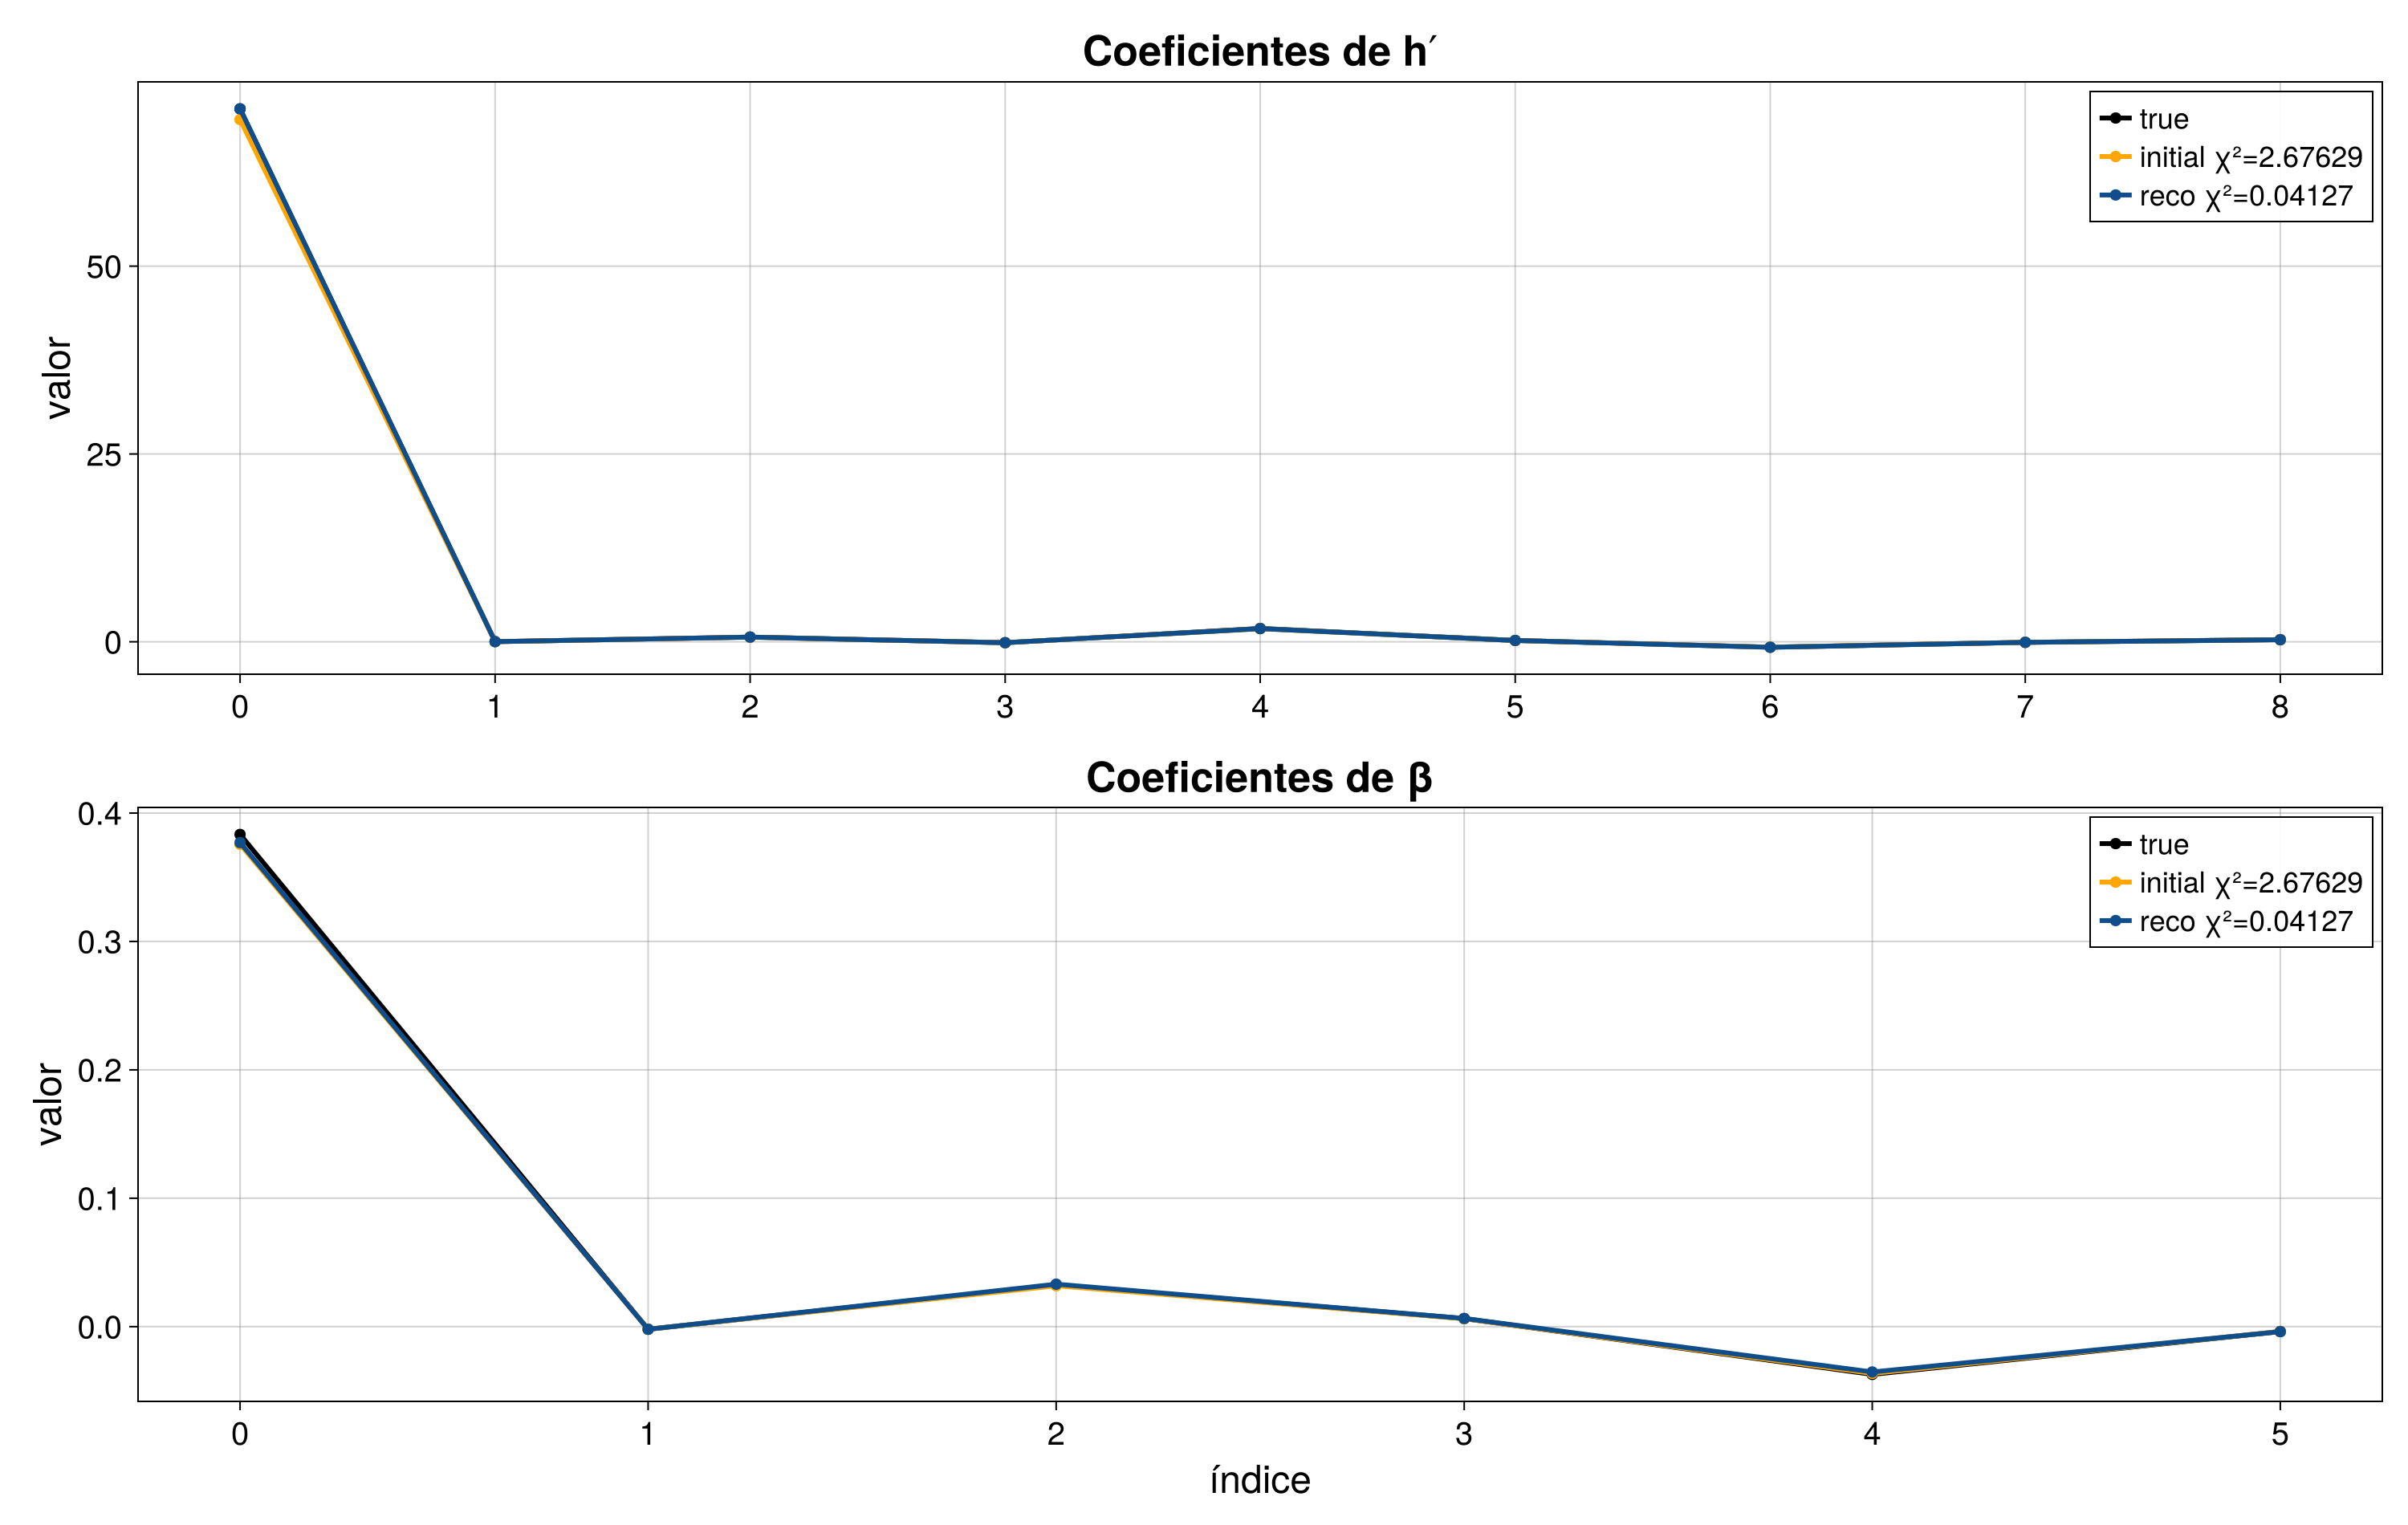

In [14]:

# =============================
# Gráfico de coeficientes h y beta
# =============================
x_h = collect(0:nh-1)
x_b = collect(0:nb-1)

figcoef = Figure(size=(1500, 950), backgroundcolor=:white)

axh = Axis(
    figcoef[1, 1],
    title = "Coeficientes de h′",
    ylabel = "valor",
    xticks = x_h
)

scatterlines!(axh, x_h, res.true_h, markersize=MS, linewidth=LW, label=lab_true, color=:black)
scatterlines!(axh, x_h, init_params[1:nh], markersize=MS, linewidth=LW, label=lab_init, color=:orange)
scatterlines!(axh, x_h, reco_params[1:nh], markersize=MS, linewidth=LW, label=lab_reco, color=:dodgerblue4)
axislegend(axh, position=:rt)

axb = Axis(
    figcoef[2, 1],
    title = "Coeficientes de β",
    xlabel = "índice",
    ylabel = "valor",
    xticks = x_b
)

scatterlines!(axb, x_b, res.true_beta, markersize=MS, linewidth=LW, label=lab_true, color=:black)
scatterlines!(axb, x_b, init_params[nh+1:end], markersize=MS, linewidth=LW, label=lab_init, color=:orange)
scatterlines!(axb, x_b, reco_params[nh+1:end], markersize=MS, linewidth=LW, label=lab_reco, color=:dodgerblue4)
axislegend(axb, position=:rt)

figcoef


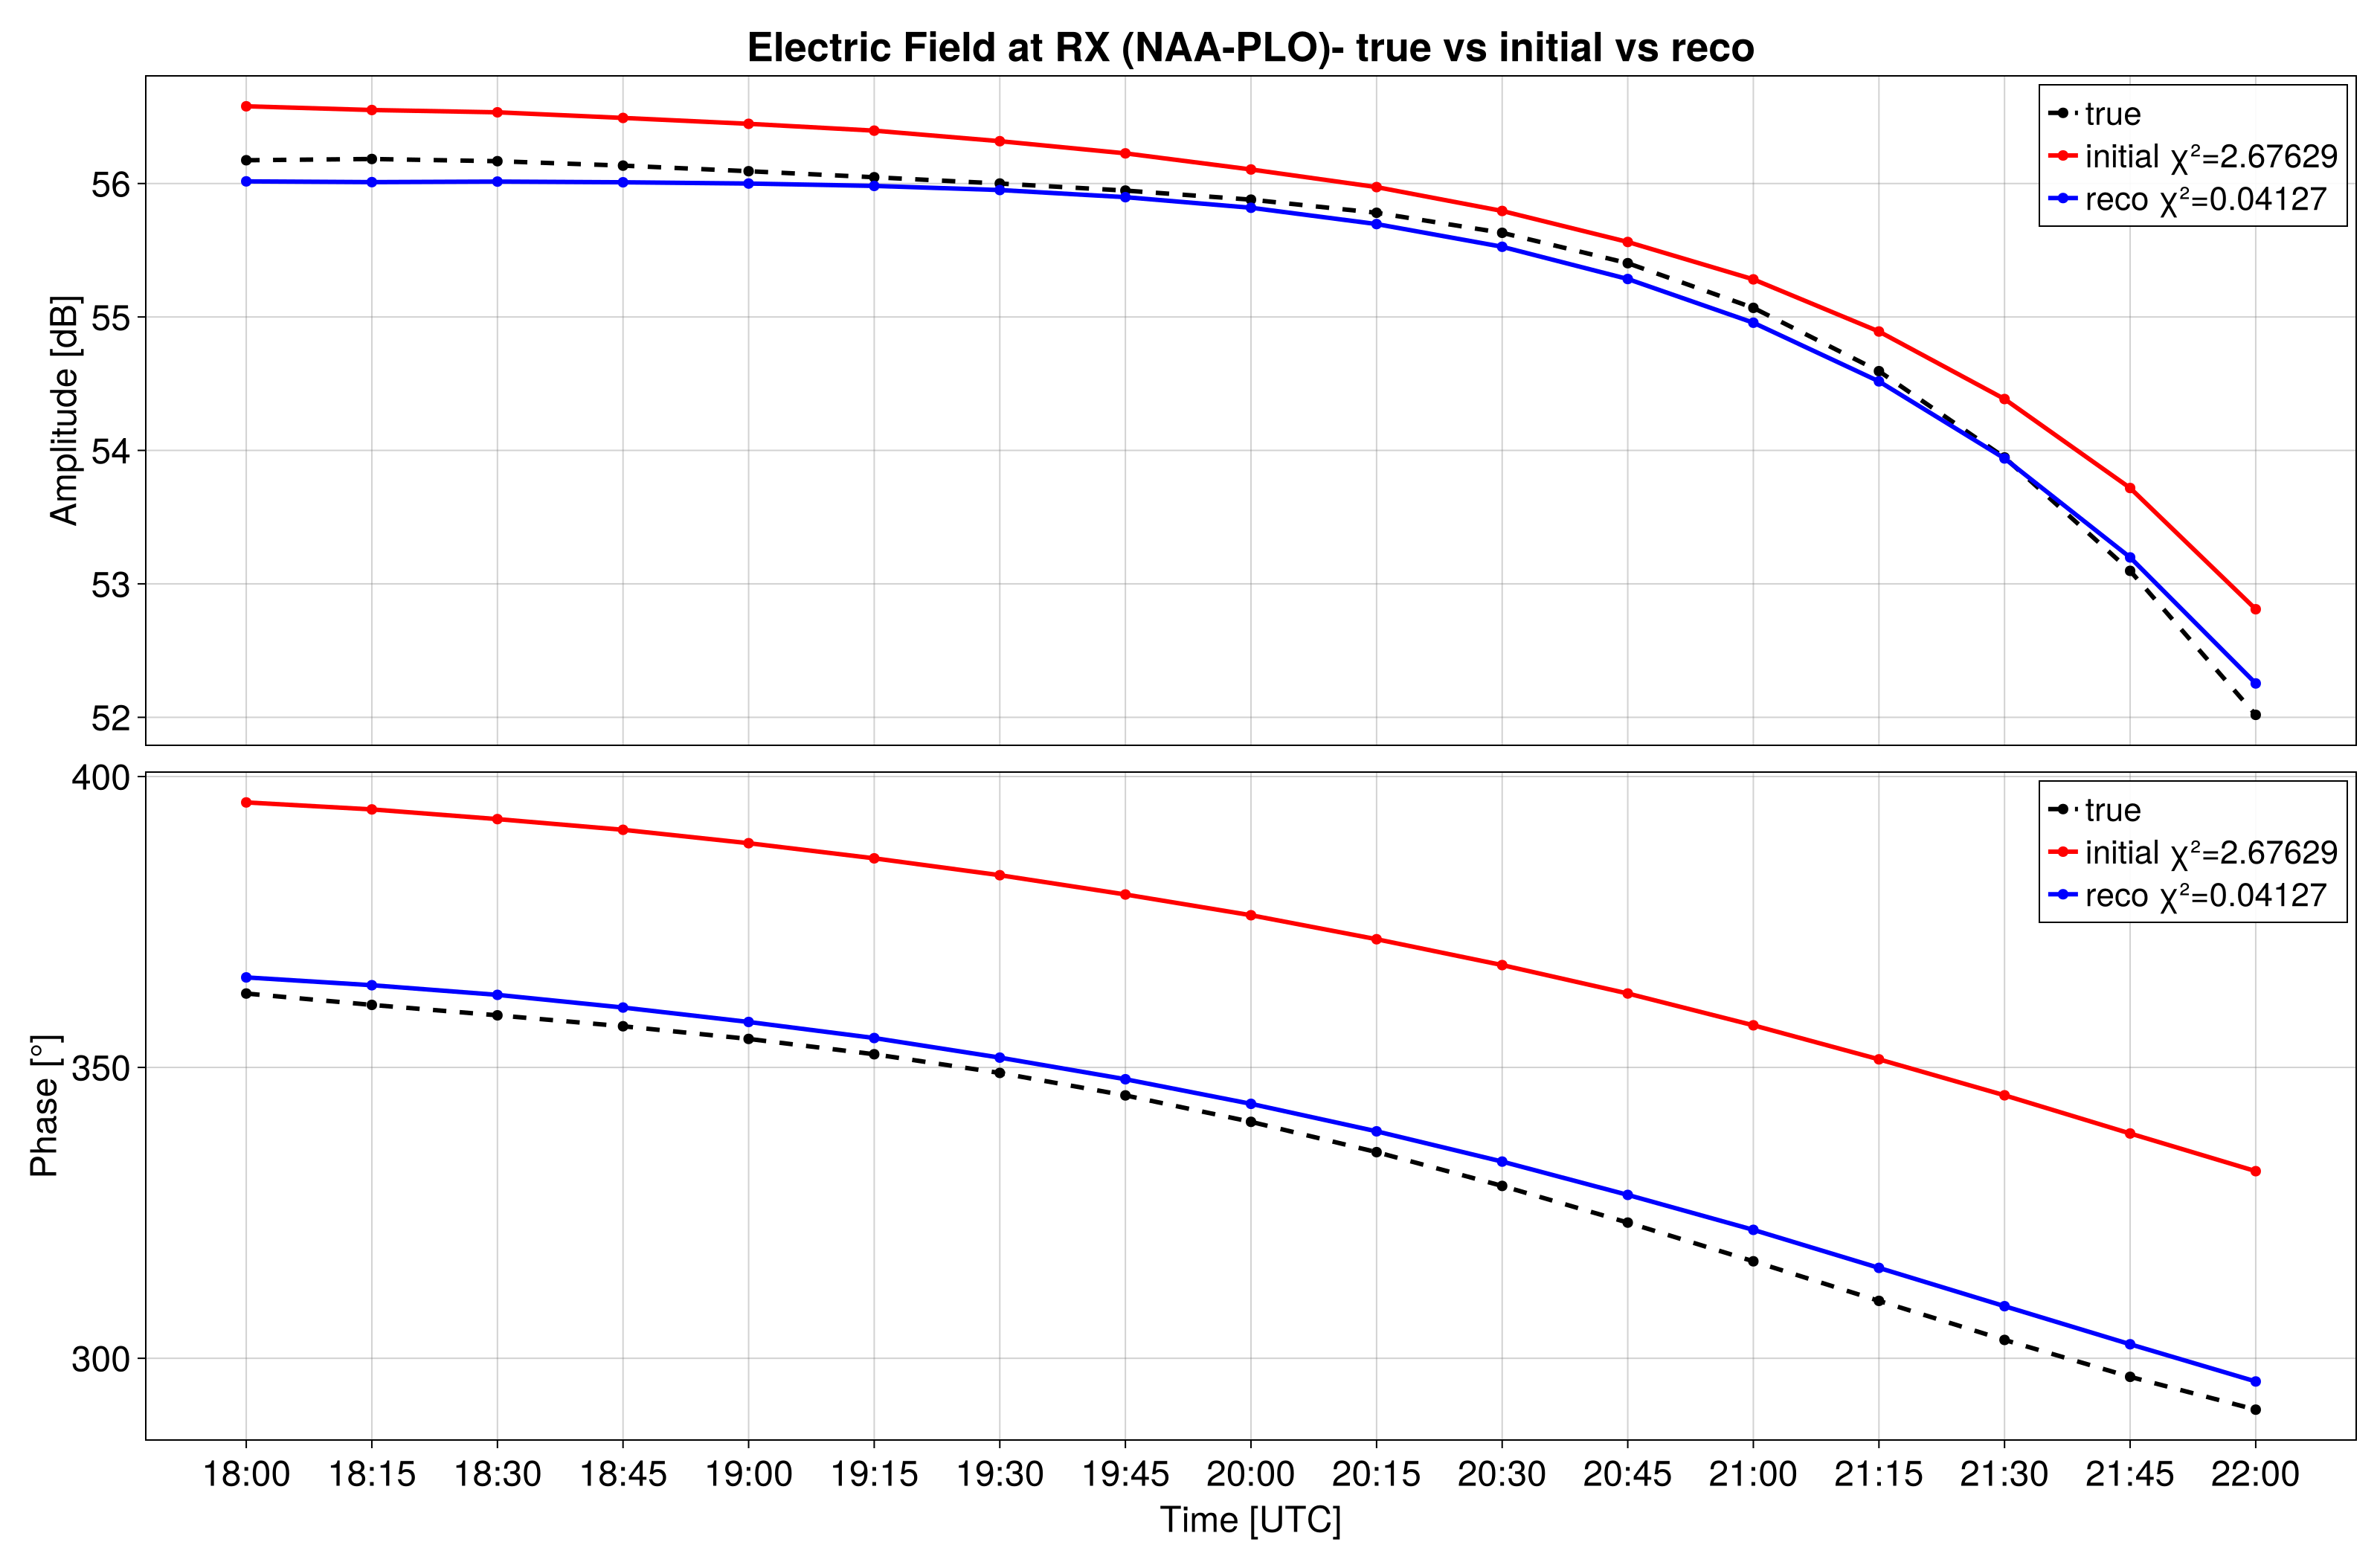

In [17]:

# =============================
# Gráfico de series temporales
# =============================
ms = 5
lw = 4
fontsize = 24
t0 = zdt_test[1]
time_hours = (datetime2unix.(DateTime.(zdt_test)) .- datetime2unix(DateTime(t0))) ./ 3600.0
xticks_numeric = time_hours
xtick_labels = Dates.format.(DateTime.(zdt_test), "HH:MM")

figts = Figure(size=(1600, 1050), backgroundcolor=:white)

axA = Axis(
    figts[1, 1],
    title = "Electric Field at RX (NAA-PLO)- true vs initial vs reco",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false,
    xlabelsize = fontsize,
    ylabelsize = fontsize,
    xticklabelsize = fontsize,
    yticklabelsize = fontsize,
    titlesize = fontsize + 3,
    titlefont = :bold,
)

scatterlines!(axA, time_hours, target_A, markersize=MS, linewidth=LW, label=lab_true, color=:black,linestyle=:dash)
scatterlines!(axA, time_hours, A_init, markersize=MS, linewidth=LW, label=lab_init, color=:red)
scatterlines!(axA, time_hours, res.A_reco, markersize=MS, linewidth=LW, label=lab_reco, color=:blue)
axislegend(axA, position=:rt,labelsize=22)

axP = Axis(
    figts[2, 1],
    #title = "Phase: true vs initial vs reco",
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0,
    xlabelsize = fontsize,
    xticklabelsize = fontsize,
    yticklabelsize = fontsize,
    ylabelsize = fontsize,
    titlesize = fontsize + 3,
    titlefont = :bold,

)

scatterlines!(axP, time_hours, target_phi, markersize=MS, linewidth=LW, label=lab_true, color=:black,linestyle=:dash)
scatterlines!(axP, time_hours, phi_init, markersize=MS, linewidth=LW, label=lab_init, color=:red)
scatterlines!(axP, time_hours, res.phi_reco, markersize=MS, linewidth=LW, label=lab_reco, color=:blue)
axislegend(axP, position=:rt,labelsize=22)

linkxaxes!(axA, axP)
save("background-inversion-synthetic-data-reco-final.pdf",figts)
figts


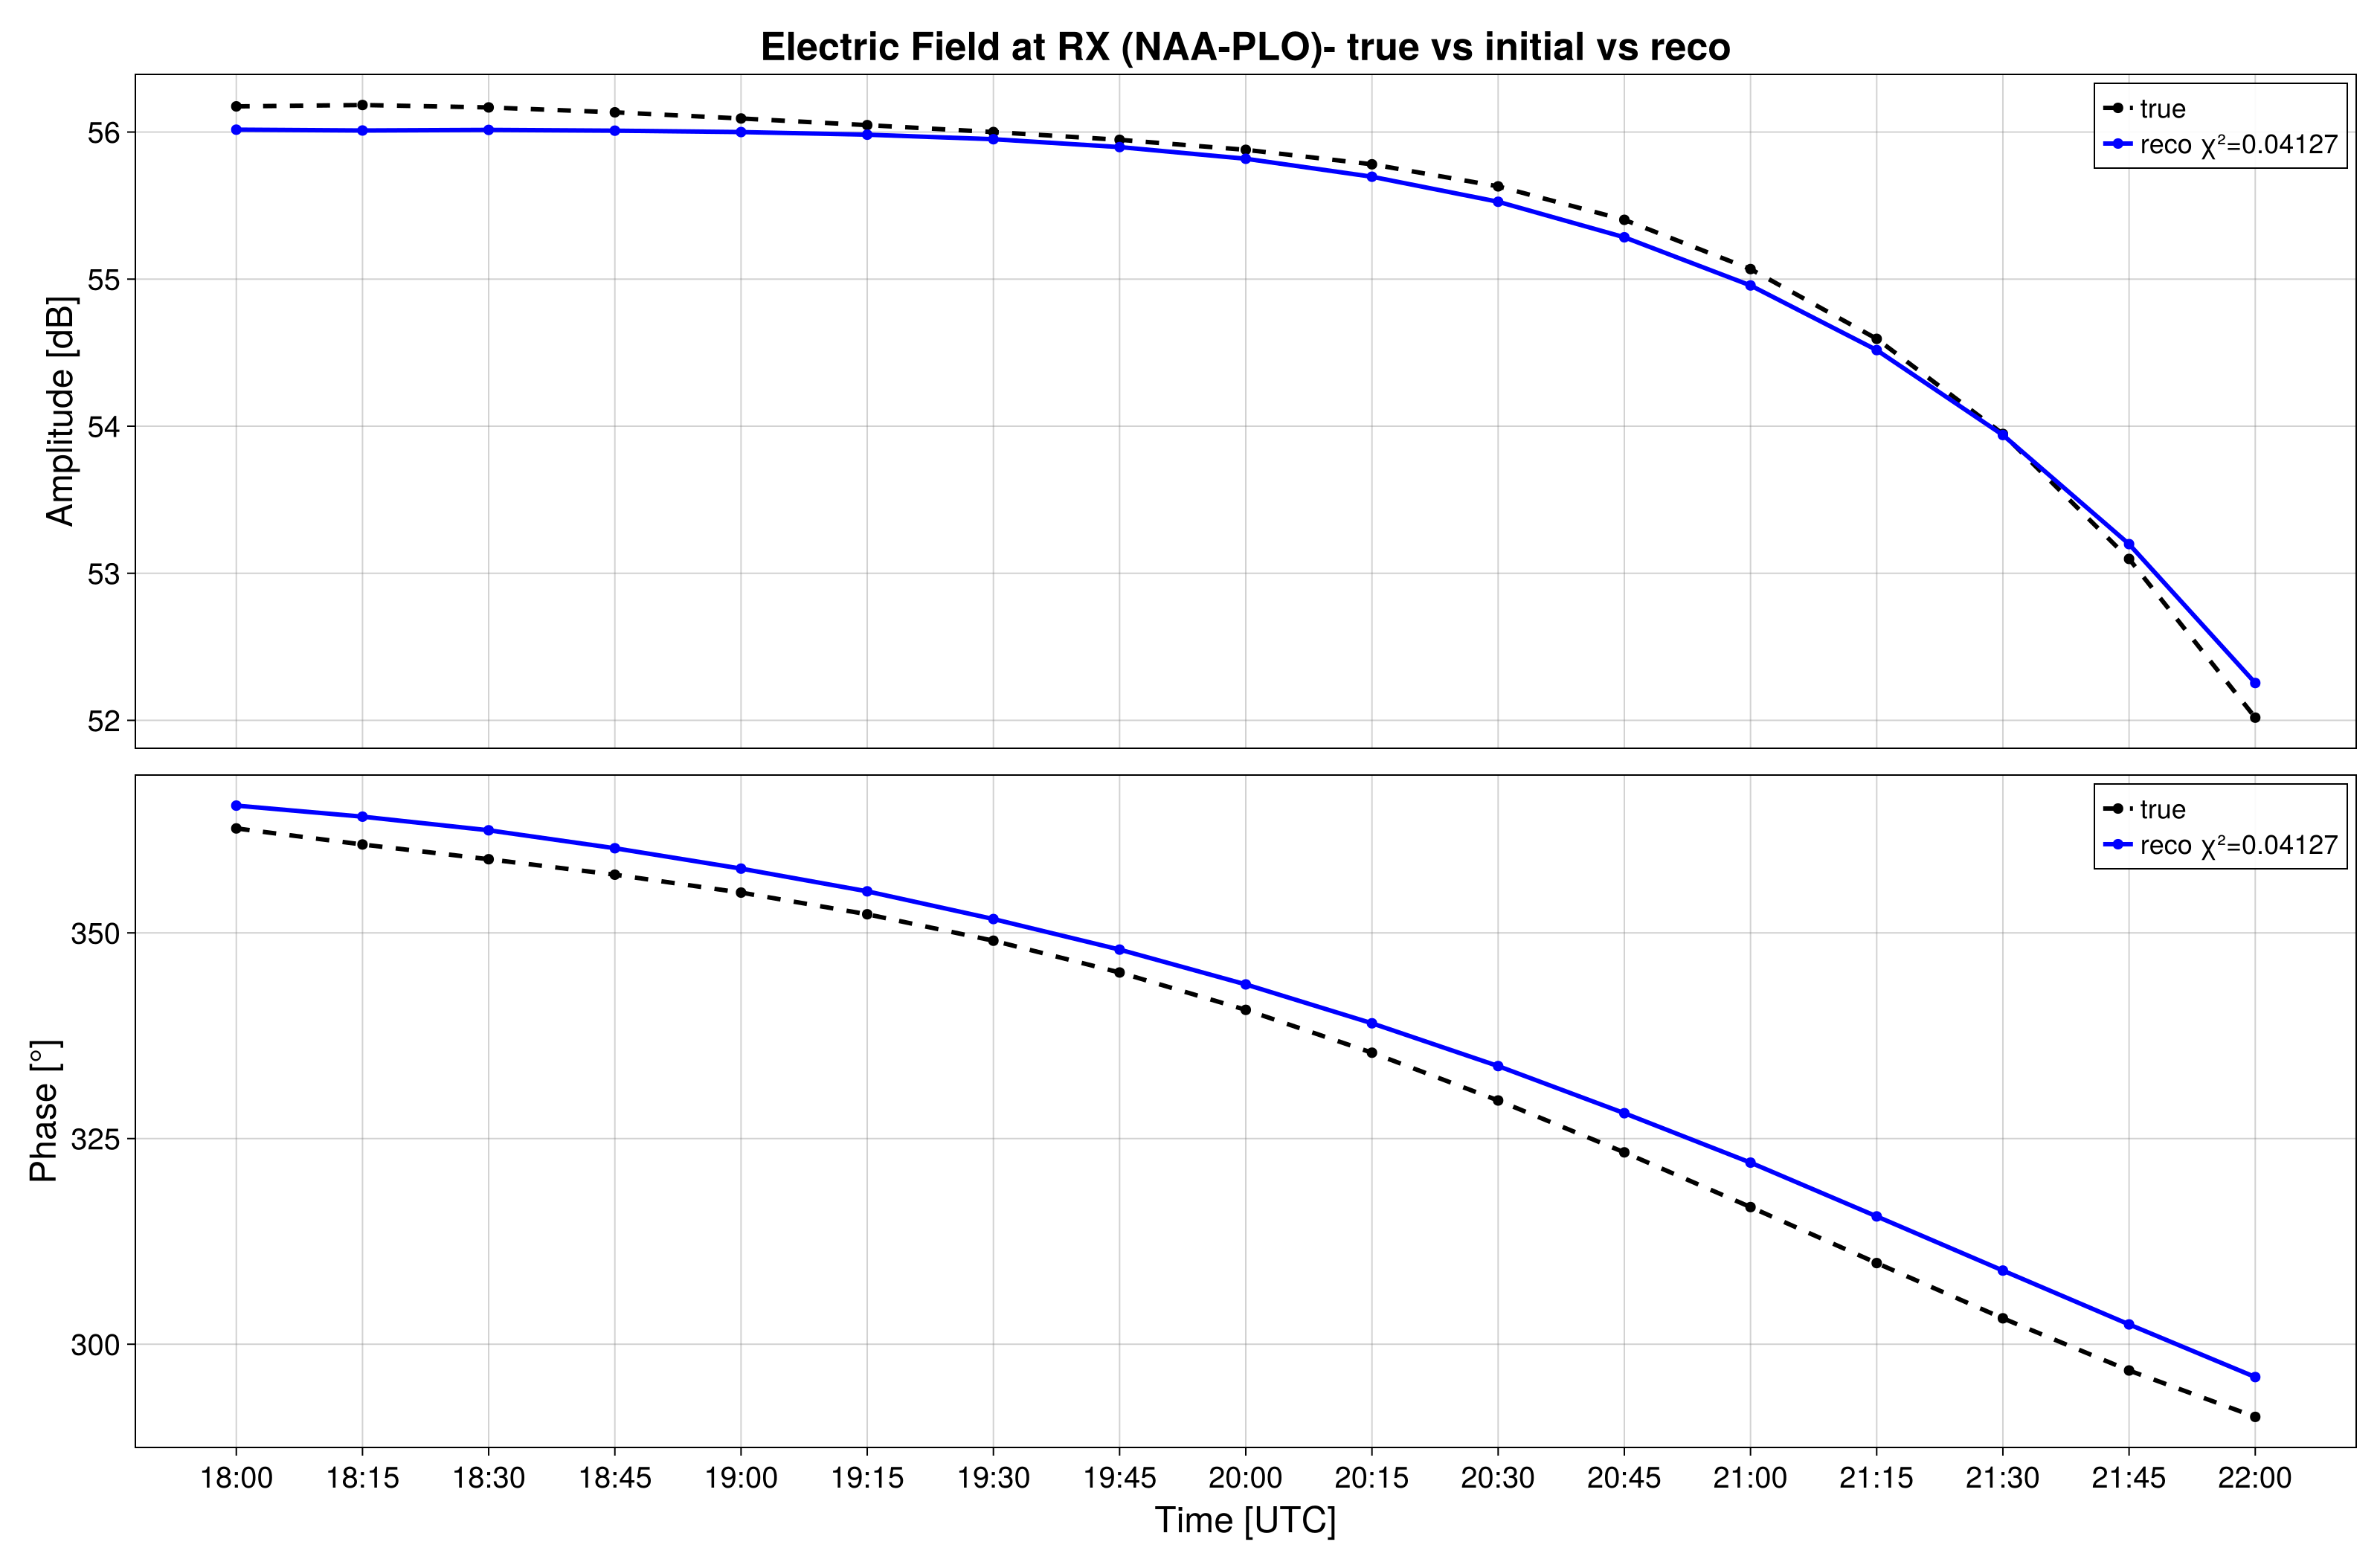

In [16]:

# =============================
# Gráfico de series temporales
# =============================
t0 = zdt_test[1]
time_hours = (datetime2unix.(DateTime.(zdt_test)) .- datetime2unix(DateTime(t0))) ./ 3600.0
xticks_numeric = time_hours
xtick_labels = Dates.format.(DateTime.(zdt_test), "HH:MM")

figts = Figure(size=(1600, 1050), backgroundcolor=:white)

axA = Axis(
    figts[1, 1],
    title = "Electric Field at RX (NAA-PLO)- true vs initial vs reco",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

scatterlines!(axA, time_hours, target_A, markersize=MS, linewidth=LW, label=lab_true, color=:black,linestyle=:dash)
#scatterlines!(axA, time_hours, A_init, markersize=MS, linewidth=LW, label=lab_init, color=:red)
scatterlines!(axA, time_hours, res.A_reco, markersize=MS, linewidth=LW, label=lab_reco, color=:blue)
axislegend(axA, position=:rt,labelsize=18)

axP = Axis(
    figts[2, 1],
    #title = "Phase: true vs initial vs reco",
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

scatterlines!(axP, time_hours, target_phi, markersize=MS, linewidth=LW, label=lab_true, color=:black,linestyle=:dash)
#scatterlines!(axP, time_hours, phi_init, markersize=MS, linewidth=LW, label=lab_init, color=:red)
scatterlines!(axP, time_hours, res.phi_reco, markersize=MS, linewidth=LW, label=lab_reco, color=:blue)
axislegend(axP, position=:rt,labelsize=18)

linkxaxes!(axA, axP)
#save("background-inversion-synthetic-data-reco-final.pdf",figts)
figts

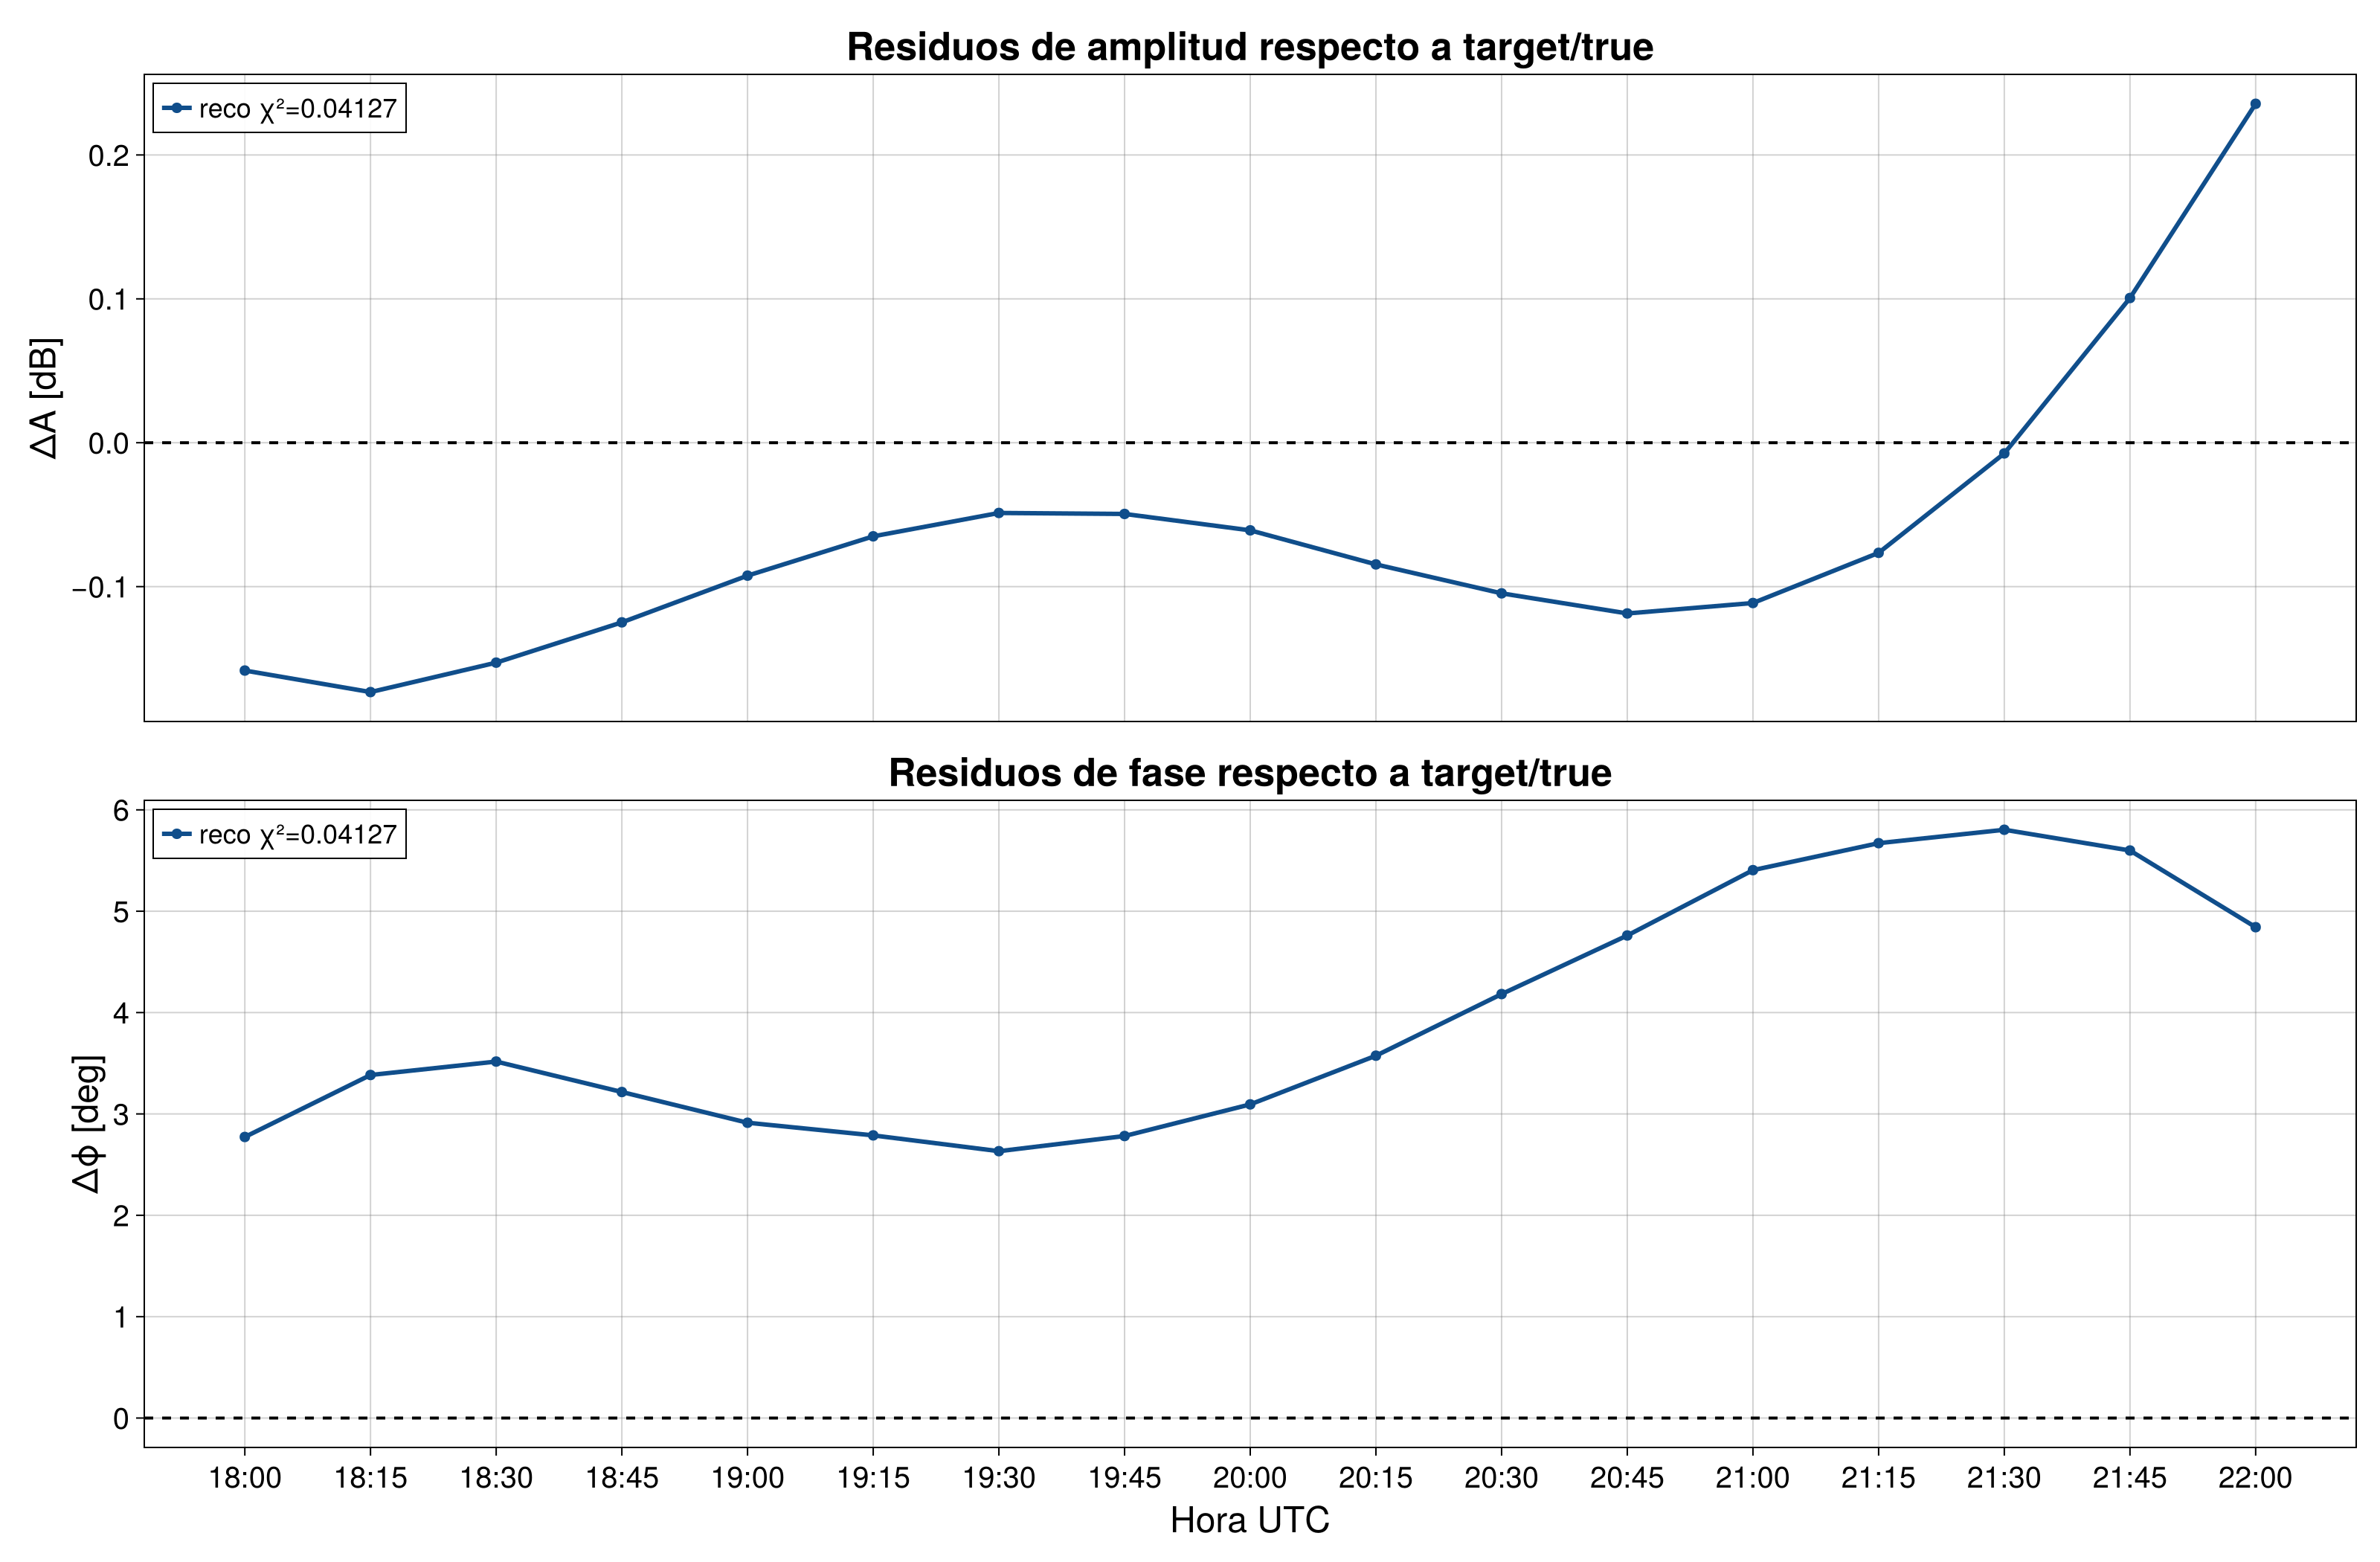

In [46]:

# =============================
# Gráfico de residuos contra target/true
# =============================
resA_init = A_init .- target_A
resA_reco = res.A_reco .- target_A

resP_init = phi_init .- target_phi
resP_reco = res.phi_reco .- target_phi

figres = Figure(size=(1600, 1050), backgroundcolor=:white)

axRA = Axis(
    figres[1, 1],
    title = "Residuos de amplitud respecto a target/true",
    ylabel = "ΔA [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

hlines!(axRA, [0.0], linewidth=2, color=:black, linestyle=:dash)
#scatterlines!(axRA, time_hours, resA_init, markersize=MS, linewidth=LW,
#              label="initial $(fmtχ(m_init))", color=:orange)
scatterlines!(axRA, time_hours, resA_reco, markersize=MS, linewidth=LW,
              label="reco $(fmtχ(m_reco))", color=:dodgerblue4)
axislegend(axRA, position=:lt)

axRP = Axis(
    figres[2, 1],
    title = "Residuos de fase respecto a target/true",
    xlabel = "Hora UTC",
    ylabel = "Δϕ [deg]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

hlines!(axRP, [0.0], linewidth=2, color=:black, linestyle=:dash)
#scatterlines!(axRP, time_hours, resP_init, markersize=MS, linewidth=LW,
#              label="initial $(fmtχ(m_init))", color=:orange)
scatterlines!(axRP, time_hours, resP_reco, markersize=MS, linewidth=LW,
              label="reco $(fmtχ(m_reco))", color=:dodgerblue4)
axislegend(axRP, position=:lt)

linkxaxes!(axRA, axRP)

figres


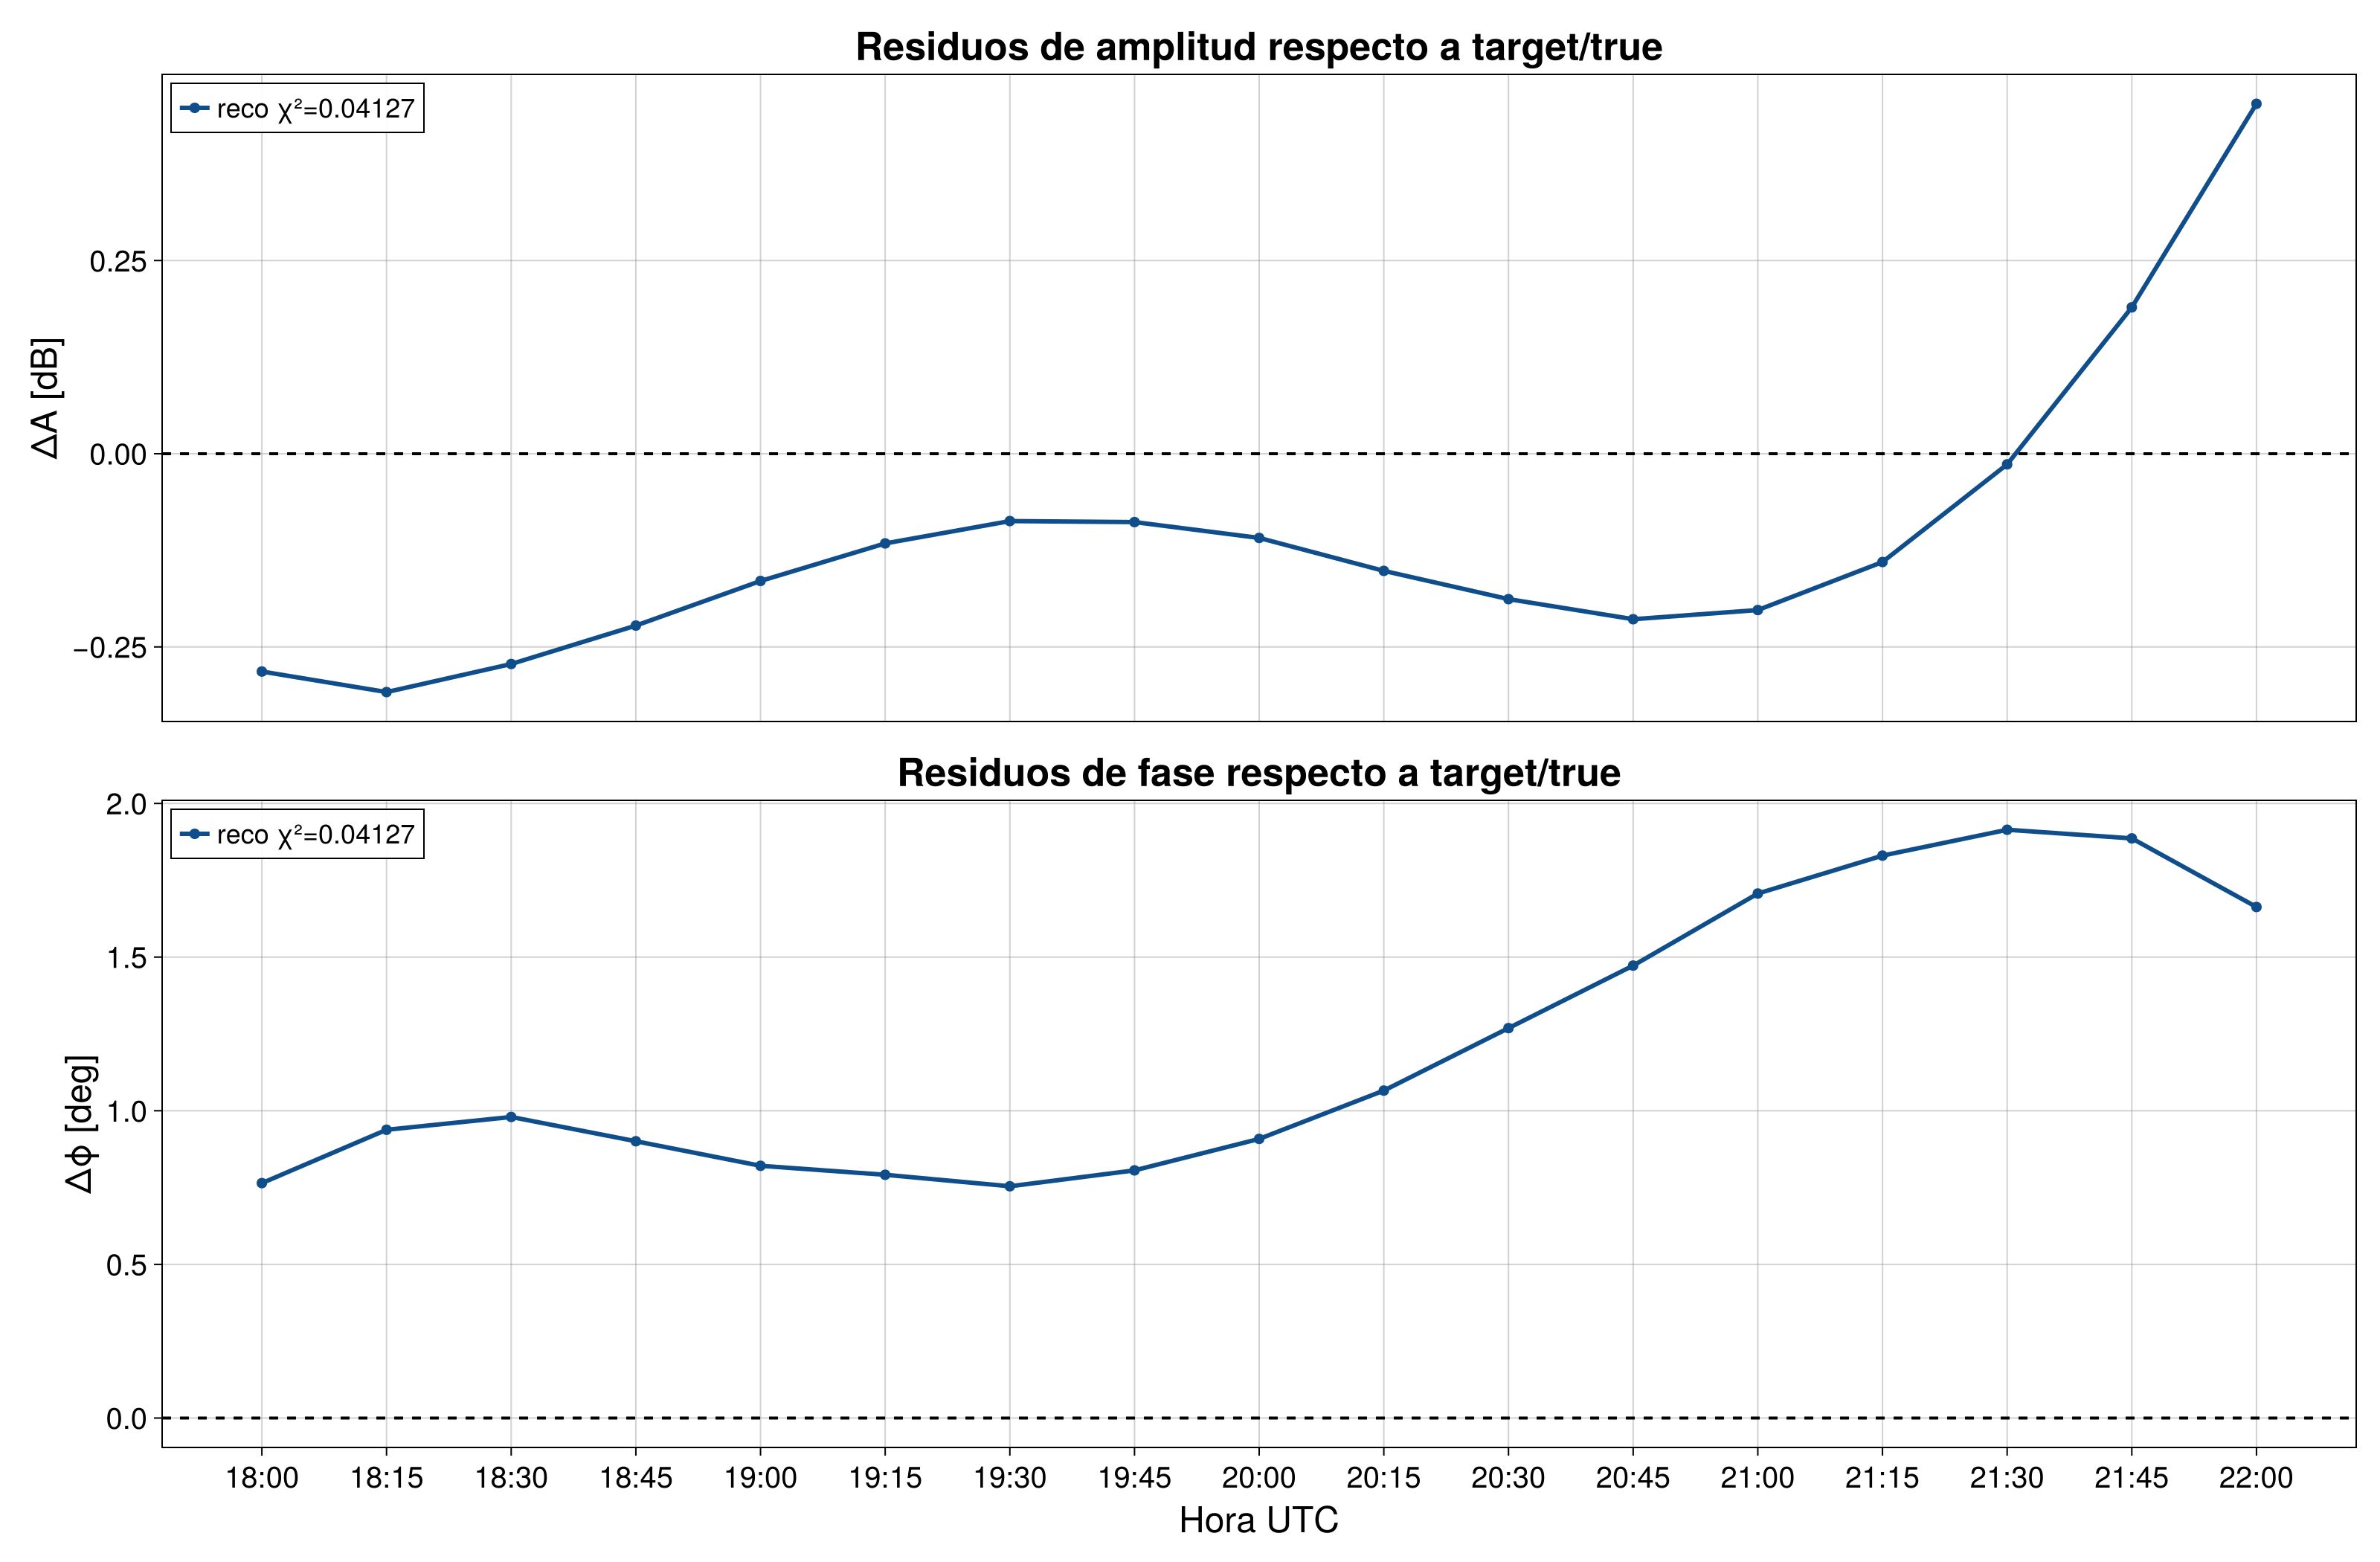

In [49]:

# =============================
# Gráfico de residuos contra target/true
# =============================
resA_init = A_init .- target_A
resA_reco = res.A_reco .- target_A

resP_init = phi_init .- target_phi
resP_reco = res.phi_reco .- target_phi

figres = Figure(size=(1600, 1050), backgroundcolor=:white)

axRA = Axis(
    figres[1, 1],
    title = "Residuos de amplitud respecto a target/true",
    ylabel = "ΔA [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

hlines!(axRA, [0.0], linewidth=2, color=:black, linestyle=:dash)
#scatterlines!(axRA, time_hours, resA_init, markersize=MS, linewidth=LW,
#              label="initial $(fmtχ(m_init))", color=:orange)
scatterlines!(axRA, time_hours, 100.0 .* resA_reco./target_A, markersize=MS, linewidth=LW,
              label="reco $(fmtχ(m_reco))", color=:dodgerblue4)
axislegend(axRA, position=:lt)

axRP = Axis(
    figres[2, 1],
    title = "Residuos de fase respecto a target/true",
    xlabel = "Hora UTC",
    ylabel = "Δϕ [deg]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

hlines!(axRP, [0.0], linewidth=2, color=:black, linestyle=:dash)
#scatterlines!(axRP, time_hours, resP_init, markersize=MS, linewidth=LW,
#              label="initial $(fmtχ(m_init))", color=:orange)
scatterlines!(axRP, time_hours, 100.0 .* resP_reco./target_phi, markersize=MS, linewidth=LW,
              label="reco $(fmtχ(m_reco))", color=:dodgerblue4)
axislegend(axRP, position=:lt)

linkxaxes!(axRA, axRP)

figres


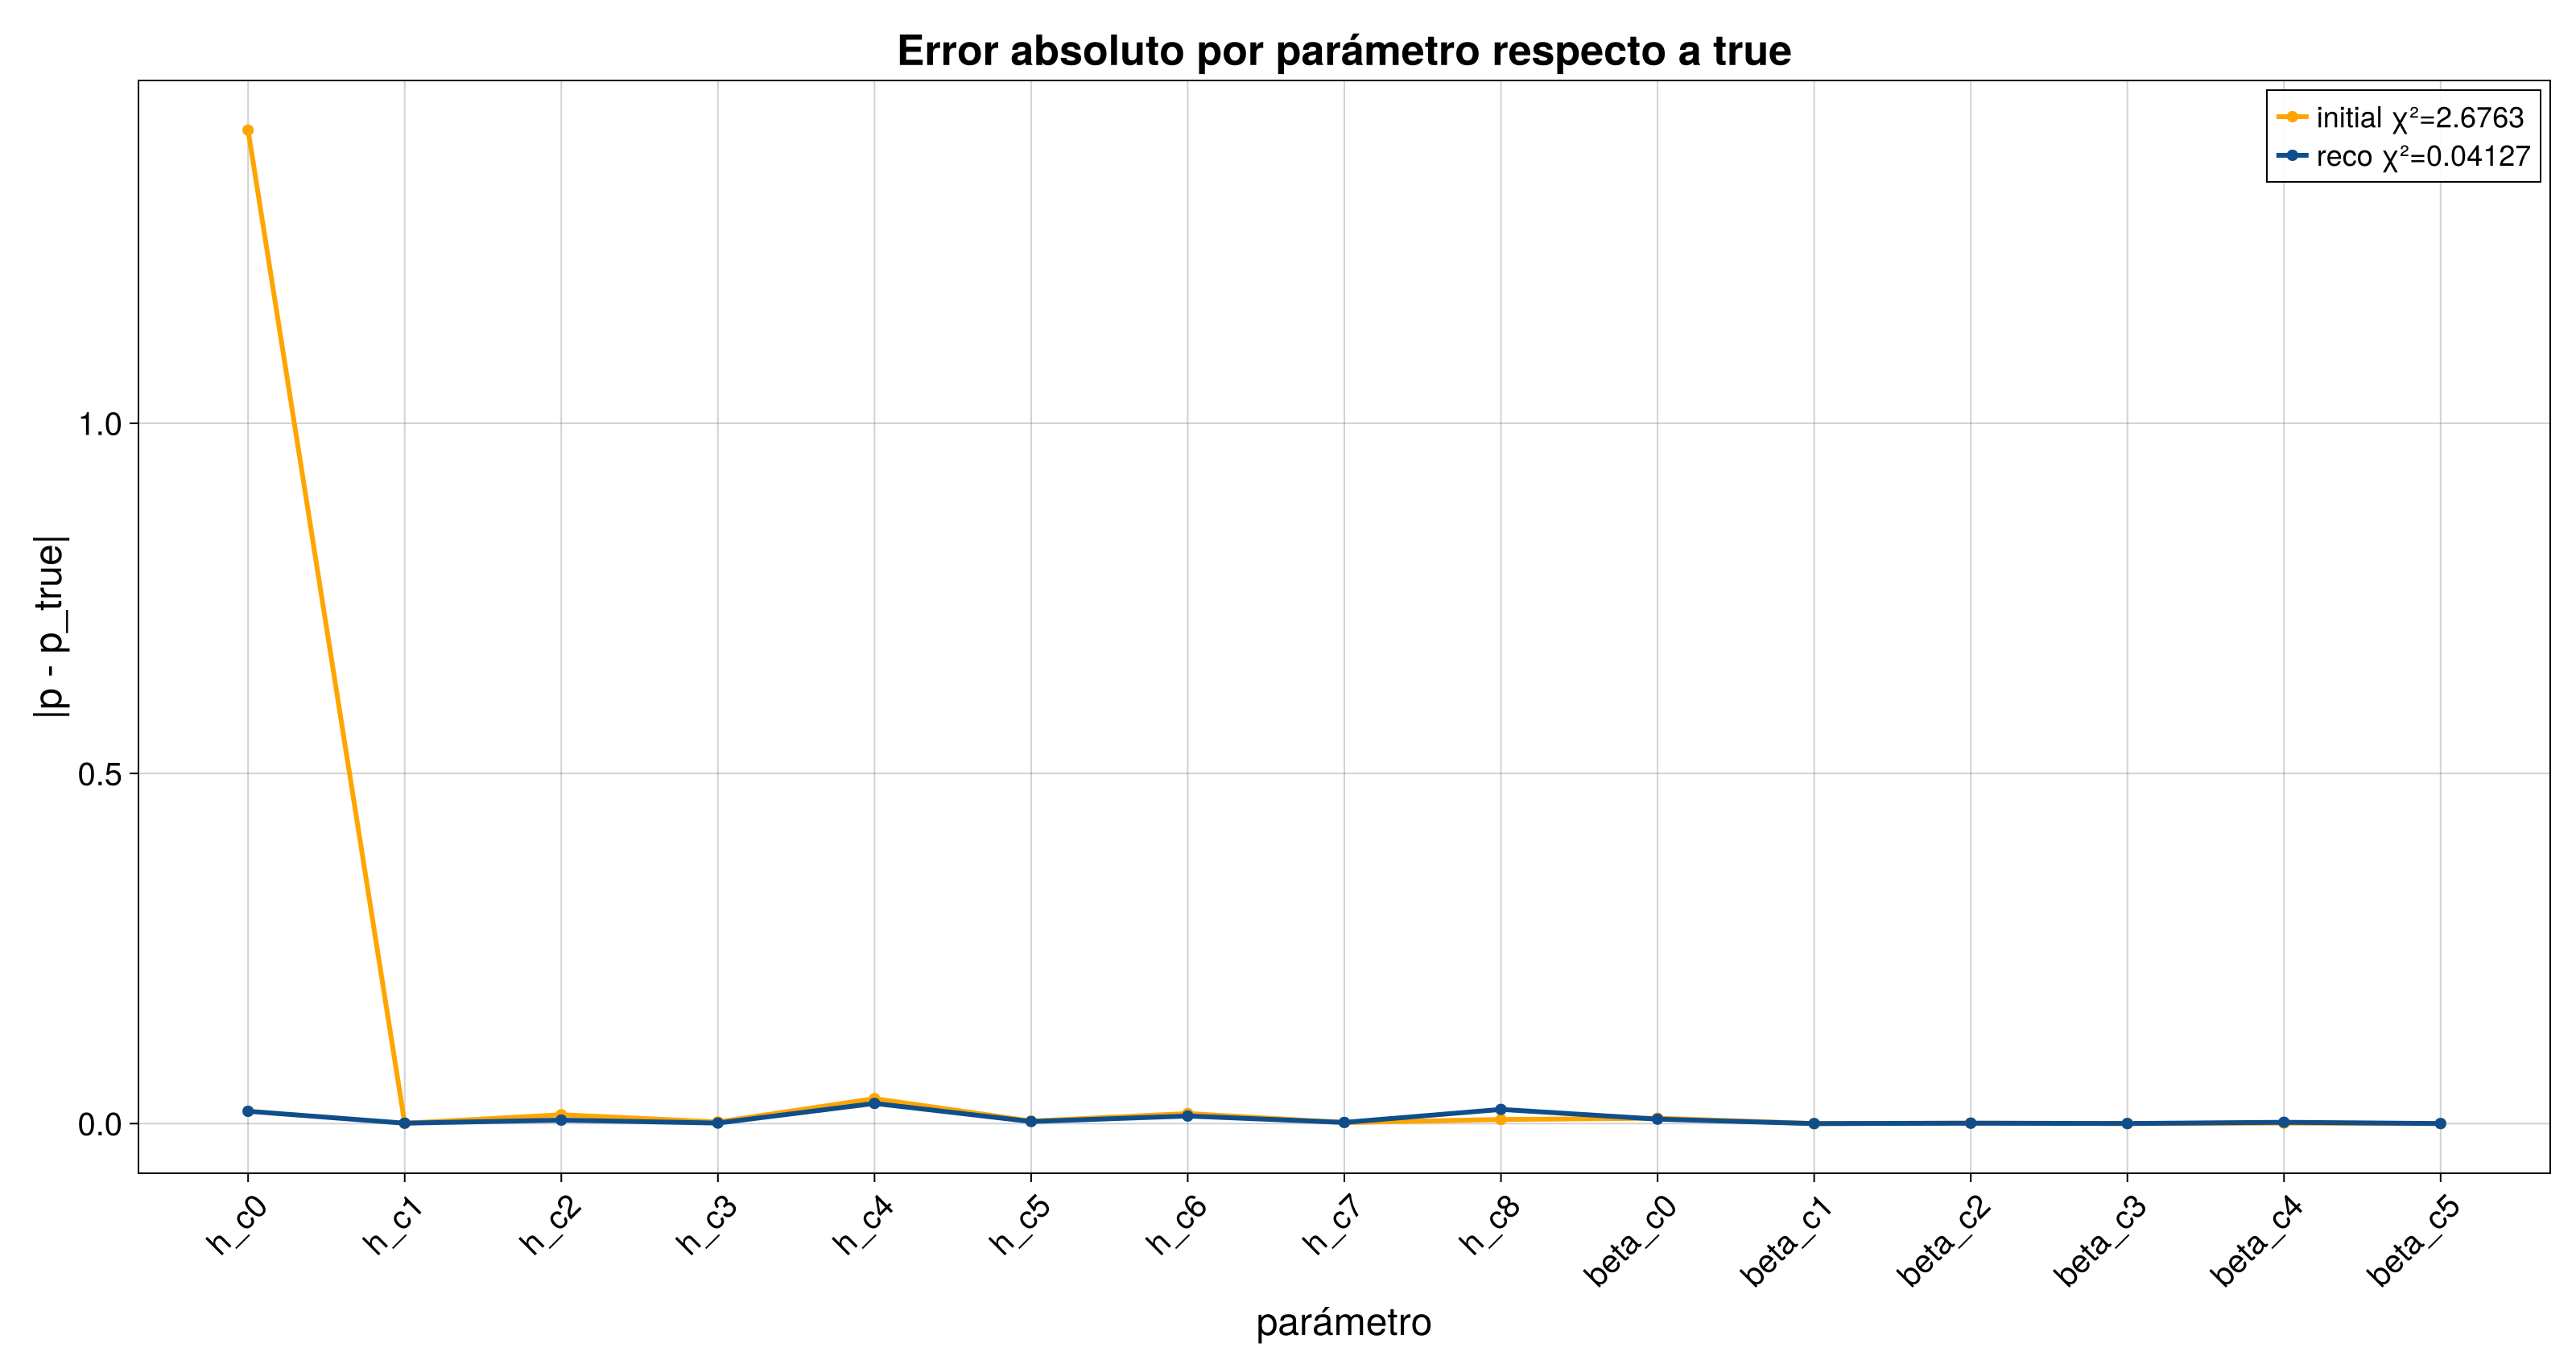

In [30]:

# =============================
# Errores absolutos por parámetro
# =============================
err_init = abs.(init_params .- true_params)
err_reco = abs.(reco_params .- true_params)

x_all = collect(1:length(true_params))

figerr = Figure(size=(1600, 850), backgroundcolor=:white)

axE = Axis(
    figerr[1, 1],
    title = "Error absoluto por parámetro respecto a true",
    xlabel = "parámetro",
    ylabel = "|p - p_true|",
    xticks = (x_all, parameter_names),
    xticklabelrotation = π/4
)

scatterlines!(axE, x_all, err_init, markersize=MS, linewidth=LW,
              label="initial $(fmtχ(m_init))", color=:orange)
scatterlines!(axE, x_all, err_reco, markersize=MS, linewidth=LW,
              label="reco $(fmtχ(m_reco))", color=:dodgerblue4)

axislegend(axE, position=:rt)

figerr


In [31]:

# =============================
# Guardado de figuras
# =============================
save("background_FIRI_seed_coefficients_true_init_reco.png", figcoef)
save("background_FIRI_seed_timeseries_true_init_reco.png", figts)
save("background_FIRI_seed_residuals_true_init_reco.png", figres)
save("background_FIRI_seed_parameter_errors.png", figerr)

println("Figuras guardadas:")
println("  background_FIRI_seed_coefficients_true_init_reco.png")
println("  background_FIRI_seed_timeseries_true_init_reco.png")
println("  background_FIRI_seed_residuals_true_init_reco.png")
println("  background_FIRI_seed_parameter_errors.png")


Figuras guardadas:
  background_FIRI_seed_coefficients_true_init_reco.png
  background_FIRI_seed_timeseries_true_init_reco.png
  background_FIRI_seed_residuals_true_init_reco.png
  background_FIRI_seed_parameter_errors.png


In [32]:

# =============================
# Conclusión automática breve
# =============================
println("Resumen:")
println("  χ² initial total = ", round(m_init.chiT, digits=8),
        "   [A=", round(m_init.chiA, digits=8),
        ", phi=", round(m_init.chiP, digits=8), "]")
println("  χ² reco total    = ", round(m_reco.chiT, digits=8),
        "   [A=", round(m_reco.chiA, digits=8),
        ", phi=", round(m_reco.chiP, digits=8), "]")

println()
println("  RMSE params initial vs true = ", round(rmse(init_params, true_params), sigdigits=8))
println("  RMSE params reco vs true    = ", round(rmse(reco_params, true_params), sigdigits=8))

if m_reco.chiT < m_init.chiT
    println("  Resultado: la reconstrucción mejora el χ² normalizado respecto al inicial.")
else
    println("  Resultado: la reconstrucción NO mejora el χ² normalizado respecto al inicial.")
end

if rmse(reco_params, true_params) < rmse(init_params, true_params)
    println("  Resultado: la reconstrucción queda más cerca de los parámetros true que el inicial.")
else
    println("  Resultado: la reconstrucción NO queda más cerca de los parámetros true que el inicial.")
end


Resumen:
  χ² initial total = 2.6762999   [A=0.10345642, phi=2.57284347]
  χ² reco total    = 0.04127194   [A=0.00973587, phi=0.03153607]

  RMSE params initial vs true = 0.36644833
  RMSE params reco vs true    = 0.010794465
  Resultado: la reconstrucción mejora el χ² normalizado respecto al inicial.
  Resultado: la reconstrucción queda más cerca de los parámetros true que el inicial.
